# Part 1 / 4 -- Data preparation & leak-free split
**Alzheimer MRI Classification -- Dual-CNN pipeline (split into 4 notebooks to fit inside one Kaggle session)**

### Kaggle setup for this notebook
- Add Input: `uraninjo/augmented-alzheimer-mri-dataset` (same as before)
- Accelerator: GPU not required for this part, but leaving it on is fine
- Internet: on (only needed later parts, harmless here)

### What this notebook does
Builds the image dataframe, hashes every file, does the group-aware leak-free
train/val/test split, and saves everything the next notebook needs.

### At the end
Click **Save Version -> Save & Run All (Commit)**. Once it finishes, this
notebook's output files (`train_df.csv`, `val_df.csv`, `test_df.csv`,
`label_classes.json`, `figures/`) become available to Part 2 by adding
**Add Input -> Notebook Output Files -> (this notebook)**.


In [1]:
# 0. Imports and reproducibility
import os, random, hashlib, warnings, json, gc
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
from pathlib import Path

# 1. Configuration
CANDIDATE_DIRS = [
    Path("/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset"),
    Path("/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset"),
]
DATA_DIR = next((p for p in CANDIDATE_DIRS if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Checked:\n" +
        "\n".join(f"  - {p}" for p in CANDIDATE_DIRS) +
        "\nAttach the dataset to this notebook (right sidebar -> Add Input)."
    )

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
TEST_SIZE = 0.20
VAL_SIZE = 0.15
SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("DATA_DIR:", DATA_DIR)
assert DATA_DIR.exists(), f"Set DATA_DIR first: {DATA_DIR}"

DATA_DIR: /kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = Path("./figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 100
print(f"Figures will be saved to: {FIG_DIR.resolve()}")

Figures will be saved to: /kaggle/working/figures


In [4]:
# 2. Build dataframe + exact-file hash
rows = []
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    for p in cls_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXT:
            rows.append({"filepath": str(p), "label": cls_dir.name})

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No images found. Check DATA_DIR.")

def sha256_file(path, chunk=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

df["file_hash"] = df["filepath"].map(sha256_file)

# BUG FIX: this dataset is flat (<class>/<file>), so parent.name == class name.
# Using it as `group` made GroupShuffleSplit split by CLASS, not by image/subject
# -- an entire class could land wholly in one partition. There is no real
# patient/subject ID available here, so the safest fallback is to group by
# file_hash: exact duplicates (same hash) are kept together in one split, and
# every other image gets its own singleton group, so the split is effectively
# per-image while still protecting against duplicate leakage.
df["group"] = df["file_hash"]

# Safety check (this is what the leakage-audit checklist below claims happens --
# it previously didn't; this makes it real): if group ever collapses to
# label-level (e.g. every image in a class ends up sharing one group value),
# GroupShuffleSplit would push whole classes into a single split. Detect and
# auto-correct to a per-image group in that case.
_unique_groups_per_label = df.groupby("label")["group"].nunique()
if (_unique_groups_per_label <= 1).any():
    print("[!] group column collapsed to label-level -- falling back to per-image grouping")
    df["group"] = df.index.astype(str)

print(df["label"].value_counts())
print("Images:", len(df), "Unique hashes:", df["file_hash"].nunique())
print("Unique groups:", df["group"].nunique())


label
NonDemented         3200
VeryMildDemented    2240
MildDemented         896
ModerateDemented      64
Name: count, dtype: int64
Images: 6400 Unique hashes: 6400
Unique groups: 6400


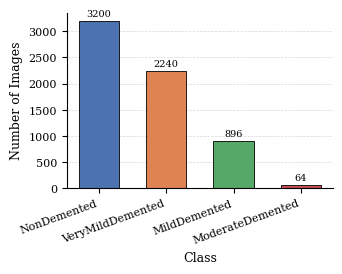

label
NonDemented         3200
VeryMildDemented    2240
MildDemented         896
ModerateDemented      64
Name: count, dtype: int64

Imbalance ratio (largest/smallest class): 50.00x


In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- IEEE style rcParams ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

class_counts = df["label"].value_counts()

# IEEE single-column width ~3.5in; use (7.16, 3) for double-column
fig, ax = plt.subplots(figsize=(3.5, 2.8))

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = ax.bar(
    class_counts.index, class_counts.values,
    color=colors[: len(class_counts)],
    edgecolor="black", linewidth=0.6, width=0.6,
)

ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.bar_label(bars, padding=2, fontsize=7)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("class_distribution.pdf")   # vector, LaTeX-e direct include korte parbi
plt.savefig("class_distribution.png", dpi=300)
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(class_counts)
print(f"\nImbalance ratio (largest/smallest class): {imbalance_ratio:.2f}x")


In [6]:
# 3. Group-aware split
gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(df, df["label"], groups=df["group"]))

trainval = df.iloc[trainval_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

val_fraction_of_trainval = VAL_SIZE / (1 - TEST_SIZE)
gss_val = GroupShuffleSplit(n_splits=1, test_size=val_fraction_of_trainval, random_state=SEED)
train_idx, val_idx = next(gss_val.split(trainval, trainval["label"], groups=trainval["group"]))

train_df = trainval.iloc[train_idx].reset_index(drop=True)
val_df   = trainval.iloc[val_idx].reset_index(drop=True)

def overlap(a, b, col):
    return len(set(a[col]) & set(b[col]))

print("Rows:", len(train_df), len(val_df), len(test_df))
print("Group overlap:", overlap(train_df,val_df,"group"),
      overlap(train_df,test_df,"group"),
      overlap(val_df,test_df,"group"))
print("Hash overlap:", overlap(train_df,test_df,"file_hash"),
      overlap(val_df,test_df,"file_hash"))

assert overlap(train_df,val_df,"group") == 0
assert overlap(train_df,test_df,"group") == 0
assert overlap(val_df,test_df,"group") == 0
assert overlap(train_df,test_df,"file_hash") == 0
assert overlap(val_df,test_df,"file_hash") == 0


Rows: 4160 960 1280
Group overlap: 0 0 0
Hash overlap: 0 0


In [7]:
# 4. Labels
le = LabelEncoder()
le.fit(df["label"])

for part in (train_df, val_df, test_df):
    part["y"] = le.transform(part["label"])

NUM_CLASSES = len(le.classes_)
print("Classes:", list(le.classes_))


Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


                  train  val  test
label                             
MildDemented        587  135   174
ModerateDemented     41    9    14
NonDemented        2053  495   652
VeryMildDemented   1479  321   440


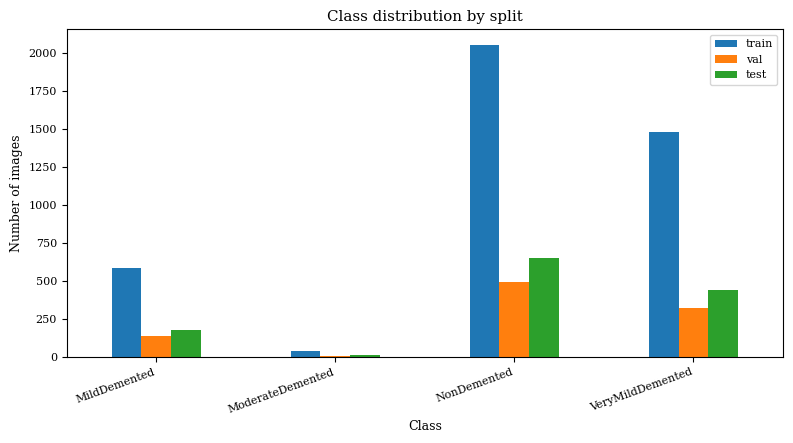


[OK] every class present in train, val, and test.


In [8]:
# 4a. Per-split class distribution
split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val":   val_df["label"].value_counts(),
    "test":  test_df["label"].value_counts(),
}).reindex(le.classes_).fillna(0).astype(int)

print(split_counts)

ax = split_counts.plot(kind="bar", figsize=(8, 4.5))
ax.set_title("Class distribution by split")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

missing = split_counts[(split_counts == 0).any(axis=1)]
if len(missing):
    print("\n[!] WARNING -- these classes are missing from at least one split:")
    print(missing)
else:
    print("\n[OK] every class present in train, val, and test.")


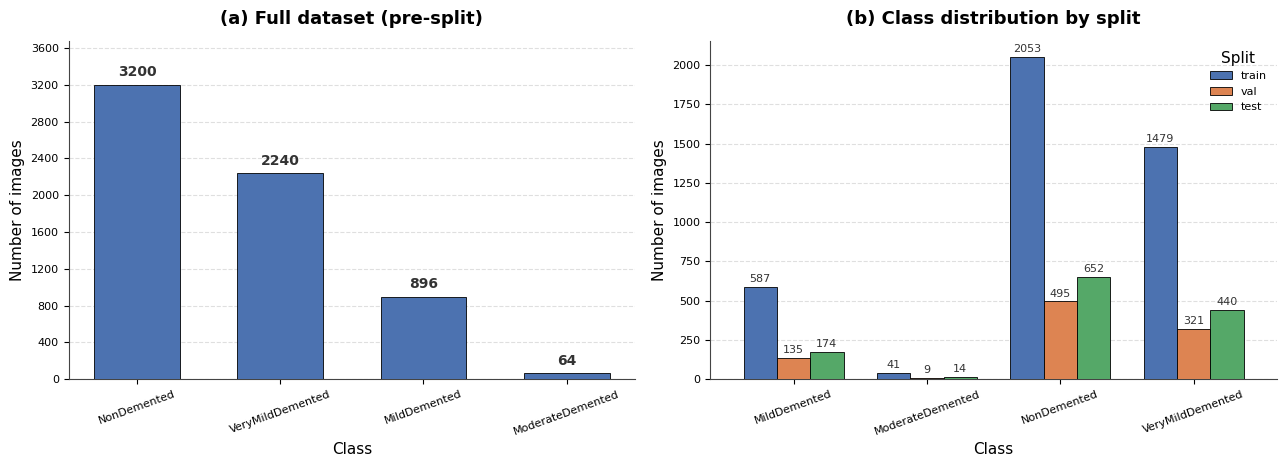

Saved: figures/Fig2_Dataset_Class_Distribution.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Global style for a clean, publication-quality look ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

sns_palette = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.patch.set_facecolor("white")

# ---------- (a) Full dataset ----------
bars = axes[0].bar(
    class_counts.index, class_counts.values,
    color="#4C72B0", edgecolor="black", linewidth=0.6, width=0.6, zorder=3
)
axes[0].set_title("(a) Full dataset (pre-split)", pad=12)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of images")
axes[0].bar_label(bars, padding=4, fontsize=10, fontweight="bold", color="#333333")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
axes[0].set_axisbelow(True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# একটু হেডরুম যাতে bar_label কেটে না যায়
axes[0].set_ylim(0, max(class_counts.values) * 1.15)

# ---------- (b) Per-split distribution ----------
split_counts.plot(
    kind="bar", ax=axes[1], color=sns_palette,
    edgecolor="black", linewidth=0.6, width=0.75, zorder=3
)
axes[1].set_title("(b) Class distribution by split", pad=12)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of images")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
axes[1].set_axisbelow(True)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].legend(title="Split", frameon=False, loc="upper right")

# optional: bar labels on stacked/grouped split chart too
for container in axes[1].containers:
    axes[1].bar_label(container, padding=2, fontsize=8, color="#333333")

plt.tight_layout()
fig2_path = FIG_DIR / "Fig2_Dataset_Class_Distribution.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {fig2_path}")

In [10]:
# 5. Image pipeline
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="train_augmentation")

def decode_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_ds(part, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (part["filepath"].values, part["y"].values)
    )
    if training:
        ds = ds.shuffle(len(part), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x,y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, True)
val_ds   = make_ds(val_df, False)
test_ds  = make_ds(test_df, False)


2026-08-29 12:32:44.436117: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


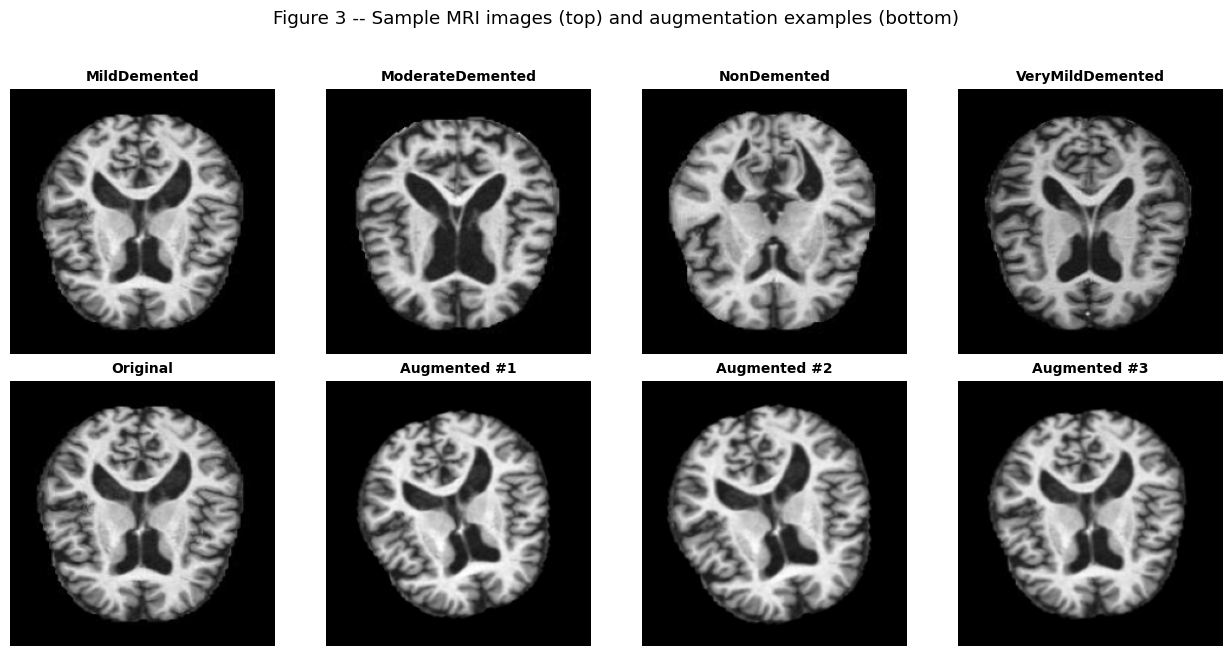

Saved: figures/Fig3_Samples_and_Augmentation.png


In [11]:
# Figure 3 -- sample MRI images (one per class) + augmentation examples
import numpy as np

classes_for_fig3 = list(le.classes_) if "le" in dir() else sorted(df["label"].unique())
n_cols_fig3 = max(len(classes_for_fig3), 4)

fig, axes = plt.subplots(2, n_cols_fig3, figsize=(3.2 * n_cols_fig3, 6.4))

# (a) top row: one sample per class
for i, cls in enumerate(classes_for_fig3):
    sample_path = df[df["label"] == cls]["filepath"].iloc[0]
    img = tf.io.read_file(sample_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE) / 255.0
    axes[0, i].imshow(img.numpy())
    axes[0, i].set_title(cls, fontsize=10)
    axes[0, i].axis("off")
for i in range(len(classes_for_fig3), n_cols_fig3):
    axes[0, i].axis("off")

# (b) bottom row: one image + augmentation variants
base_path = df["filepath"].iloc[0]
base_img = tf.io.read_file(base_path)
base_img = tf.image.decode_image(base_img, channels=3, expand_animations=False)
base_img = tf.cast(tf.image.resize(base_img, IMG_SIZE), tf.float32) / 255.0

axes[1, 0].imshow(base_img.numpy())
axes[1, 0].set_title("Original", fontsize=10)
axes[1, 0].axis("off")

for j in range(1, n_cols_fig3):
    # augment expects unbatched (224, 224, 3) input here, since that's how
    # it was built inside the tf.data pipeline (mapped before .batch())
    aug_img = augment(base_img, training=True)
    axes[1, j].imshow(np.clip(aug_img.numpy(), 0, 1))
    axes[1, j].set_title(f"Augmented #{j}", fontsize=10)
    axes[1, j].axis("off")

plt.suptitle("Figure 3 -- Sample MRI images (top) and augmentation examples (bottom)", y=1.02)
plt.tight_layout()
fig3_path = FIG_DIR / "Fig3_Samples_and_Augmentation.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig3_path}")

## Save checkpoint for Part 2
Saves the split dataframes (with `filepath`, `label`, `file_hash`, `group`, `y` columns) and the class list.

In [12]:
# Save checkpoint artifacts for Part 2
train_df.to_csv("/kaggle/working/train_df.csv", index=False)
val_df.to_csv("/kaggle/working/val_df.csv", index=False)
test_df.to_csv("/kaggle/working/test_df.csv", index=False)

with open("/kaggle/working/label_classes.json", "w") as f:
    json.dump(list(le.classes_), f)

print("Saved: train_df.csv, val_df.csv, test_df.csv, label_classes.json")
print("Now: Save Version -> Save & Run All (Commit), then use this notebook's")
print("output as an input source in Part 2 (Add Input -> Notebook Output Files).")


Saved: train_df.csv, val_df.csv, test_df.csv, label_classes.json
Now: Save Version -> Save & Run All (Commit), then use this notebook's
output as an input source in Part 2 (Add Input -> Notebook Output Files).
